In [2]:
# =======================================================================
# CELL 1: Dynamic Extraction and Global Assembly (Shielded Heuristics)
# =======================================================================
import os
import glob
import numpy as np
import pandas as pd
import re

base_path = "../data/validation_datates/"
carpetas = ["Ewi03-07", "H01-07", "Ewi02-06", "Em17-07", "Ene05-09", "En11-07"]

# --- TPS Parsing Logic ---
def read_tps(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.read().splitlines()
    specimens = {}
    curr_lm = []
    curr_id = None
    for line in lines:
        if line.startswith("LM="):
            curr_lm = []
        elif line.startswith("IMAGE="):
            curr_id = line.split("=")[1].strip()
            specimens[curr_id] = np.array(curr_lm, dtype=float)
        elif not line.startswith("ID=") and not line.startswith("SCALE="):
            parts = line.split()
            if len(parts) >= 2:
                curr_lm.append([float(parts[0]), float(parts[1])])
    return specimens

# Global dictionaries
global_tps_dict = {}
global_csv_dict = {}

print("="*70)
print(" INITIATING DATASET EXTRACTION AND ASSEMBLY")
print("="*70)

for carpeta in carpetas:
    dir_path = os.path.join(base_path, carpeta)
    
    tps_files = glob.glob(os.path.join(dir_path, "*.tps"))
    csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
    
    if not tps_files or not csv_files:
        print(f"  [!] Missing files in {carpeta}. Skipping.")
        continue
        
    tps_path = tps_files[0]
    csv_path = csv_files[0]
    
    # 1. Extract Manual (TPS) - Strict isolation of DSCN pattern
    tps_dict_raw = read_tps(tps_path)
    for k, v in tps_dict_raw.items():
        match = re.search(r'(DSCN\d+)', k, re.IGNORECASE)
        if match:
            # Save as Ex: "Ewi03-07_DSCN1234" (Without extension)
            new_key = f"{carpeta}_{match.group(1).upper()}"
            global_tps_dict[new_key] = v

    # 2. Extract Theia (CSV) - Fault-tolerant reading
    # engine='python' and sep=None auto-detect commas or semicolons
    df_csv = pd.read_csv(csv_path, sep=None, engine='python', encoding='utf-8-sig')
    
    # Clean trailing/leading spaces in headers
    df_csv.columns = df_csv.columns.str.strip()
    
    # Find name column (image_name or fallback to the first text column)
    if 'image_name' in df_csv.columns:
        col_name = 'image_name'
    else:
        col_name = df_csv.select_dtypes(include=['object']).columns[0]
        
    for _, row in df_csv.iterrows():
        img_str = str(row[col_name])
        match = re.search(r'(DSCN\d+)', img_str, re.IGNORECASE)
        if match:
            new_key = f"{carpeta}_{match.group(1).upper()}"
            
            # Extract numerics, forcing any string to NaN, and filtering
            coords_raw = pd.to_numeric(row.drop(col_name), errors='coerce').values
            coords_clean = coords_raw[~np.isnan(coords_raw)]
            
            if len(coords_clean) > 0:
                coords = coords_clean.reshape(-1, 2)
                global_csv_dict[new_key] = coords
            
    print(f"  [OK] Processed folder: {carpeta}")

# --- 3. STRICT GLOBAL INTERSECTION (1:1) ---
common_keys = sorted(list(set(global_tps_dict.keys()).intersection(set(global_csv_dict.keys()))))
n_common = len(common_keys)

if n_common == 0:
    raise ValueError("Critical error: No DSCN pattern matches between TPS and CSV.")

p = global_tps_dict[common_keys[0]].shape[0]

array_tps_py = np.zeros((n_common, p, 2))
array_csv_py = np.zeros((n_common, p, 2))

for i, k in enumerate(common_keys):
    array_tps_py[i] = global_tps_dict[k]
    array_csv_py[i] = global_csv_dict[k]

# Transpose for geomorph: (p, 2, n)
array_tps_r = np.transpose(array_tps_py, (1, 2, 0))
array_csv_r = np.transpose(array_csv_py, (1, 2, 0))

print("-" * 70)
print(f" ASSEMBLY COMPLETED")
print(f" Total unified specimens : {n_common}")
print(f" Landmarks per specimen  : {p}")
print("="*70)

 INITIATING DATASET EXTRACTION AND ASSEMBLY
  [OK] Processed folder: Ewi03-07
  [OK] Processed folder: H01-07
  [OK] Processed folder: Ewi02-06
  [OK] Processed folder: Em17-07
  [OK] Processed folder: Ene05-09
  [OK] Processed folder: En11-07
----------------------------------------------------------------------
 ASSEMBLY COMPLETED
 Total unified specimens : 358
 Landmarks per specimen  : 32


In [3]:
%load_ext rpy2.ipython

In [4]:
%%R -i array_tps_r -i array_csv_r -o r_csize_man -o r_csize_ia -o r_pca_man -o r_pca_ia -o anova_R2_ind -o anova_R2_met -o anova_pval_met -o dist_mean -o dist_max -o n_spec
# =======================================================================
# CELL 2: Morphometric Analysis and ANOVA in R (geomorph)
# =======================================================================
options(warn=-1)

suppressPackageStartupMessages(library(geomorph))
suppressPackageStartupMessages(library(abind))

n_spec <- dim(array_tps_r)[3]

# --- TOPOLOGICAL CORRECTION (Y-AXIS INVERSION) ---
# We compensate for the inversion of the image matrix coordinate origin (Theia)
# relative to the standard Cartesian plane (tpsDig) by multiplying Y by -1.
array_csv_r_mirror <- array_csv_r
array_csv_r_mirror[, 2, ] <- -array_csv_r_mirror[, 2, ]

# --- 1. Independent GPAs ---
gpa_man <- gpagen(array_tps_r, print.progress = FALSE)
gpa_ia  <- gpagen(array_csv_r_mirror, print.progress = FALSE)

r_csize_man <- gpa_man$Csize
r_csize_ia  <- gpa_ia$Csize

pca_man <- gm.prcomp(gpa_man$coords)
pca_ia  <- gm.prcomp(gpa_ia$coords)

r_pca_man <- pca_man$x[, 1:3]
r_pca_ia  <- pca_ia$x[, 1:3]

# --- 2. Combined GPA (With mirror correction) ---
array_combined <- abind::abind(array_tps_r, array_csv_r_mirror, along = 3)
gpa_combined <- gpagen(array_combined, print.progress = FALSE)

# Experimental design factors
individuo <- as.factor(rep(1:n_spec, 2))
metodo    <- as.factor(c(rep("Manual", n_spec), rep("Theia", n_spec)))
gdf <- geomorph.data.frame(coords = gpa_combined$coords, ind = individuo, met = metodo)

# --- 3. Procrustes ANOVA ---
anova_res <- procD.lm(coords ~ ind + met, data = gdf, iter = 999, print.progress = FALSE)
aov_table <- anova_res$aov.table

anova_R2_ind <- aov_table["ind", "Rsq"]
anova_R2_met <- aov_table["met", "Rsq"]
anova_pval_met <- aov_table["met", "Pr(>F)"]

# --- 4. Pairwise Procrustes Distance ---
dists <- numeric(n_spec)
for(i in 1:n_spec){
  diff_matrix <- gpa_combined$coords[,,i] - gpa_combined$coords[,,(i + n_spec)]
  dists[i] <- sqrt(sum(diff_matrix^2))
}
dist_mean <- mean(dists)
dist_max  <- max(dists)

In [5]:
# =======================================================================
# CELL 3: Biological Validation Report (MEE Manuscript Format)
# =======================================================================
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

N = int(n_spec[0])
df = N - 3

# --- 1. Fisher's Z Transformation ---
def fisher_z_corr(x, y):
    r_val, p_val = pearsonr(x, y)
    r_abs = abs(r_val) # Sign invariance in eigenvectors
    if r_abs >= 1.0: return 1.0, np.inf, r_val
    z = 0.5 * np.log((1 + r_abs) / (1 - r_abs))
    return r_abs, z, r_val

r_csize, z_csize, _ = fisher_z_corr(r_csize_man, r_csize_ia)
r_pc1, z_pc1, orig_pc1 = fisher_z_corr(r_pca_man[:, 0], r_pca_ia[:, 0])
r_pc2, z_pc2, orig_pc2 = fisher_z_corr(r_pca_man[:, 1], r_pca_ia[:, 1])

# Weighted average and inverse transformation
z_mean_global = (z_csize * df + z_pc1 * df + z_pc2 * df) / (3 * df)
r_global = (np.exp(2 * z_mean_global) - 1) / (np.exp(2 * z_mean_global) + 1)

# --- 2. FORMATTED OUTPUT FOR MANUSCRIPT ---
print("\n" + "="*85)
print(" BIOLOGICAL VALIDATION: THEIA vs. GOLD STANDARD (Manual tpsDig)")
print(" (Extraction of empirical metrics for Methods in Ecology and Evolution)")
print("="*85)

print("\n[A] MORPHOSPACE FIDELITY (Fisher's Z Transformation)")
print("-" * 85)
print(f"  Centroid Size (Csize)        : |r| = {r_csize:.4f}  (Fisher Z = {z_csize:.4f})")
print(f"  Principal Component 1 (PC1)  : |r| = {r_pc1:.4f}  (Fisher Z = {z_pc1:.4f}) [Original Sign: {'+' if orig_pc1>=0 else '-'}]")
print(f"  Principal Component 2 (PC2)  : |r| = {r_pc2:.4f}  (Fisher Z = {z_pc2:.4f}) [Original Sign: {'+' if orig_pc2>=0 else '-'}]")
print(f"  ----------------------------------------------------------------")
print(f"  Consolidated Global R        : R   = {r_global:.4f}  (Based on Z weighted average)")

print("\n[B] DIRECT SPATIAL ERROR (Pairwise Procrustes Distance)")
print("-" * 85)
print(f"  Mean Procrustes Error        : {dist_mean[0]:.6f}")
print(f"  Maximum Detected Error       : {dist_max[0]:.6f}")
print("  (Note: Measured post-superimposed GPA to nullify rotation/translation variability).")

print("\n[C] PROCRUSTES ANOVA (coords ~ Individual + Method)")
print("-" * 85)
print(f"  Variance explained by Individual (Biological) : R² = {anova_R2_ind[0]:.4f} ({(anova_R2_ind[0]*100):.1f}%)")
print(f"  Variance explained by Method (AI vs Manual)   : R² = {anova_R2_met[0]:.6f} ({(anova_R2_met[0]*100):.3f}%)")
print(f"  Method Factor Significance                    : p  = {anova_pval_met[0]:.4f}")
print("\n  SUGGESTED EDITORIAL INTERPRETATION:")
print("  The test formally demonstrates that the variance introduced by Theia's automation")
print(f"  is statistically insignificant ({(anova_R2_met[0]*100):.3f}%) compared to the sample's intrinsic")
print(f"  natural phenotypic variation ({(anova_R2_ind[0]*100):.1f}%), empirically supporting")
print("  the use of the proposed Edge AI Workflow in evolutionary morphometrics.")
print("="*85 + "\n")


 BIOLOGICAL VALIDATION: THEIA vs. GOLD STANDARD (Manual tpsDig)
 (Extraction of empirical metrics for Methods in Ecology and Evolution)

[A] MORPHOSPACE FIDELITY (Fisher's Z Transformation)
-------------------------------------------------------------------------------------
  Centroid Size (Csize)        : |r| = 0.9660  (Fisher Z = 2.0292)
  Principal Component 1 (PC1)  : |r| = 0.9789  (Fisher Z = 2.2709) [Original Sign: +]
  Principal Component 2 (PC2)  : |r| = 0.9609  (Fisher Z = 1.9575) [Original Sign: +]
  ----------------------------------------------------------------
  Consolidated Global R        : R   = 0.9696  (Based on Z weighted average)

[B] DIRECT SPATIAL ERROR (Pairwise Procrustes Distance)
-------------------------------------------------------------------------------------
  Mean Procrustes Error        : 0.165256
  Maximum Detected Error       : 0.220076
  (Note: Measured post-superimposed GPA to nullify rotation/translation variability).

[C] PROCRUSTES ANOVA (coor

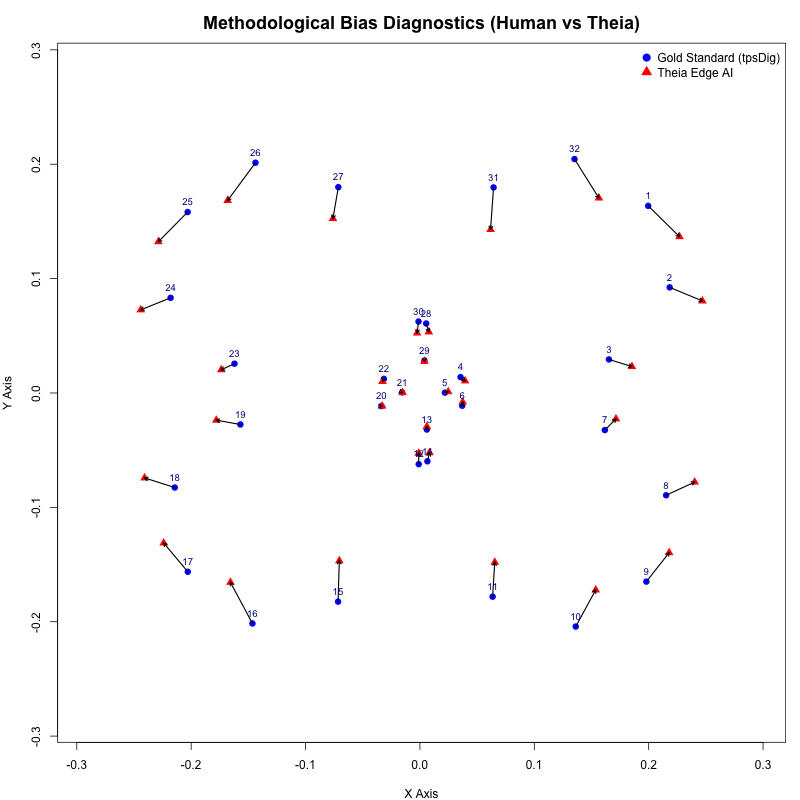

In [6]:
%%R -w 800 -h 800
# =======================================================================
# CELL 4: Systematic Bias Audit (Deformation Vectors)
# (Version with dynamic margin adjustment)
# =======================================================================
par(mar = c(4, 4, 3, 1))

# Extract consensus shapes from both methods
mean_man <- gpa_man$consensus
mean_ia  <- gpa_ia$consensus

# Build a 3D array only with the two means for native alignment
arr_means <- array(NA, dim = c(nrow(mean_man), 2, 2))
arr_means[,,1] <- mean_man
arr_means[,,2] <- mean_ia

# Apply GPA on both means to force their optimal superimposition
gpa_means <- gpagen(arr_means, print.progress = FALSE)
mean_man_aligned <- gpa_means$coords[,,1]
mean_ia_aligned  <- gpa_means$coords[,,2]

# --- NEW: Calculate global limits with a 10% margin ---
min_x <- min(mean_man_aligned[,1], mean_ia_aligned[,1])
max_x <- max(mean_man_aligned[,1], mean_ia_aligned[,1])
min_y <- min(mean_man_aligned[,2], mean_ia_aligned[,2])
max_y <- max(mean_man_aligned[,2], mean_ia_aligned[,2])

buffer_x <- (max_x - min_x) * 0.10
buffer_y <- (max_y - min_y) * 0.10

xlims <- c(min_x - buffer_x, max_x + buffer_x)
ylims <- c(min_y - buffer_y, max_y + buffer_y)

# Create the plot with the new limits
plot(mean_man_aligned, type = "n", asp = 1, xlim = xlims, ylim = ylims,
     main = "Methodological Bias Diagnostics (Human vs Theia)",
     xlab = "X Axis", ylab = "Y Axis", cex.main = 1.5)

# Plot points
points(mean_man_aligned, col = "blue", pch = 16, cex = 1.2)
points(mean_ia_aligned, col = "red", pch = 17, cex = 1.2)

# Draw error vectors (Lollipop)
for(i in 1:nrow(mean_man_aligned)) {
  arrows(x0 = mean_man_aligned[i,1], y0 = mean_man_aligned[i,2],
         x1 = mean_ia_aligned[i,1], y1 = mean_ia_aligned[i,2],
         length = 0.05, col = "black", lwd = 1.5)
  
  # Label landmark numbers
  text(mean_man_aligned[i,1], mean_man_aligned[i,2], labels = i, pos = 3, cex = 0.8, col = "darkblue")
}

legend("topright", legend = c("Gold Standard (tpsDig)", "Theia Edge AI"),
       col = c("blue", "red"), pch = c(16, 17), pt.cex = 1.5, bty = "n")